<a href="https://colab.research.google.com/github/1112hass/donor_ml/blob/main/MLF_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
projects = pd.read_csv('/content/drive/MyDrive/projects.csv')
outcomes = pd.read_csv('/content/drive/MyDrive/outcomes.csv')
essays = pd.read_csv('/content/drive/MyDrive/essays.csv')
resources = pd.read_csv('/content/drive/MyDrive/resources.csv')
# donations = pd.read_csv('/content/drive/MyDrive/donations.csv')

In [ ]:
# Keep a copy of raw group info
demographics = df[['poverty_level', 'school_metro']]


In [ ]:
# Combine all essay fields into a single text and compute essay length
essays['full_essay'] = (
    essays['title'].fillna('') + ' ' +
    essays['short_description'].fillna('') + ' ' +
    essays['need_statement'].fillna('') + ' ' +
    essays['essay'].fillna('')
)
essays['essay_length'] = essays['full_essay'].apply(lambda x: len(str(x).split()))
essays_features = essays[['projectid', 'essay_length']]


In [ ]:
# Aggregate resource stats by project
resources['total_cost'] = resources['item_unit_price'] * resources['item_quantity']
resource_summary = resources.groupby('projectid').agg({
    'item_quantity': 'sum',
    'item_unit_price': ['mean', 'max'],
    'total_cost': ['sum', 'mean']
}).reset_index()

# Flatten column names
resource_summary.columns = [
    'projectid', 'total_quantity', 'avg_unit_price', 'max_unit_price',
    'total_cost', 'avg_total_cost'
]


In [ ]:
# # Convert timestamp to datetime
# # Convert timestamp to datetime, handling errors and inferring format
# donations['donation_timestamp'] = pd.to_datetime(donations['donation_timestamp'], errors='coerce', infer_datetime_format=True)
# # Donation summary per project
# donation_summary = donations.groupby('projectid').agg({
#     'donation_to_project': ['count', 'sum', 'mean'],
#     'donation_timestamp': ['min', 'max'],
#     'donor_acctid': pd.Series.nunique
# }).reset_index()

# donation_summary.columns = [
#     'projectid', 'donation_count', 'donation_sum', 'donation_mean',
#     'first_donation', 'last_donation', 'unique_donors'
# ]

# # Add donation span in days
# donation_summary['donation_duration'] = (
#     donation_summary['last_donation'] - donation_summary['first_donation']
# ).dt.days.fillna(0)


In [ ]:
project_features = projects[[
    'projectid', 'teacher_acctid', 'schoolid', 'school_city', 'school_state', 'school_metro',
    'school_charter', 'school_magnet', 'teacher_prefix', 'teacher_teach_for_america',
    'primary_focus_subject', 'primary_focus_area', 'poverty_level', 'grade_level',
    'total_price_excluding_optional_support', 'students_reached',
    'eligible_double_your_impact_match', 'eligible_almost_home_match'
]]


In [ ]:
df = project_features.copy()

# Join engineered features
df = df.merge(essays_features, on='projectid', how='left')
df = df.merge(resource_summary, on='projectid', how='left')
# df = df.merge(donation_summary, on='projectid', how='left')
df = df.merge(outcomes[['projectid', 'fully_funded']], on='projectid', how='inner')  # only training data

# Target: binary 1/0
df['fully_funded'] = df['fully_funded'].map({'t': 1, 'f': 0})
# Keep a copy of raw group info
demographics = df[['poverty_level', 'school_metro']]

In [ ]:
# Step 1: Drop IDs and high-cardinality fields BEFORE encoding
df = df.drop(columns=['projectid', 'teacher_acctid', 'schoolid', 'school_city'])

# Step 2: Select manageable categorical columns for encoding
cat_cols = df.select_dtypes(include='object').columns

# Step 3: Fill missing values and encode
df[cat_cols] = df[cat_cols].fillna('missing')
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [ ]:
X = df.drop(columns=['fully_funded'])
y = df['fully_funded']

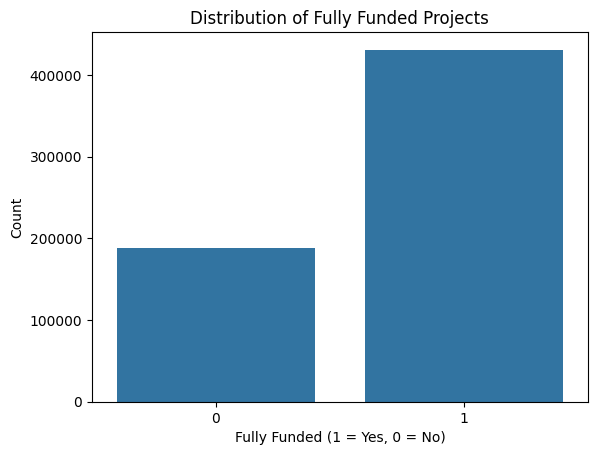

Funding Class Proportion:
 fully_funded
1    0.695406
0    0.304594
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(x='fully_funded', data=df)
plt.title('Distribution of Fully Funded Projects')
plt.xlabel('Fully Funded (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

# Ratio
funding_ratio = df['fully_funded'].value_counts(normalize=True)
print("Funding Class Proportion:\n", funding_ratio)


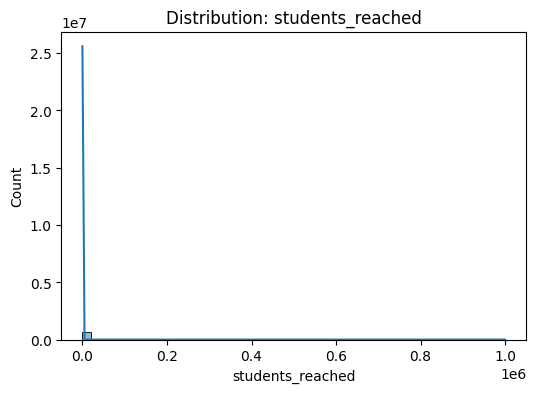

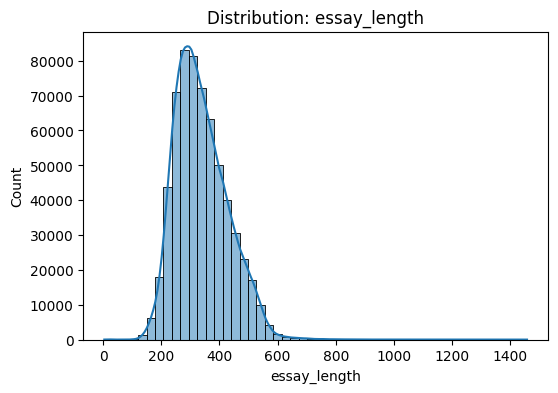

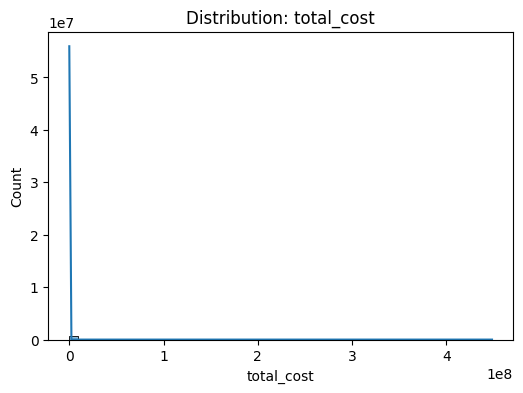

In [ ]:
num_features = [
    'students_reached', 'essay_length', 'total_cost',
    'donation_sum', 'donation_count', 'donation_duration'
]

for col in num_features:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], bins=50, kde=True)
        plt.title(f'Distribution: {col}')
        plt.show()


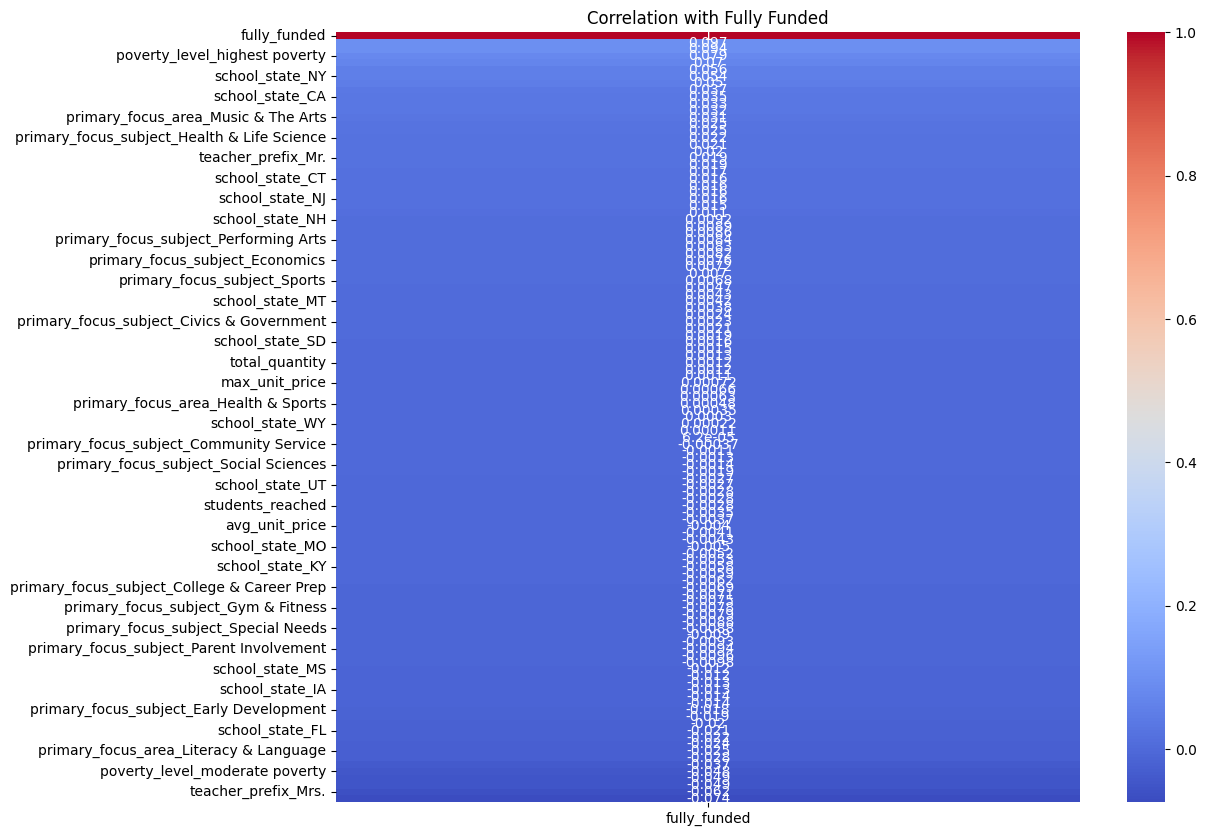

In [ ]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr[['fully_funded']].sort_values(by='fully_funded', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation with Fully Funded')
plt.show()


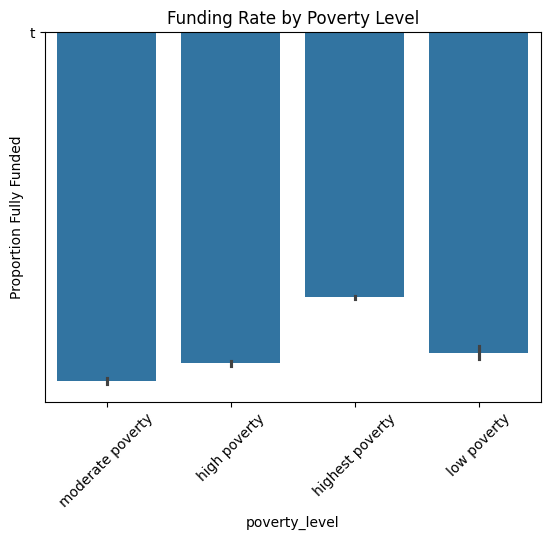

In [ ]:
# Example: Funding success by poverty level
if 'poverty_level_missing' in df.columns:
    print("Note: one-hot encoded, can't group directly")

else:
    sns.barplot(x='poverty_level', y='fully_funded', data=projects.merge(outcomes, on='projectid'))
    plt.title('Funding Rate by Poverty Level')
    plt.ylabel('Proportion Fully Funded')
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['fully_funded'])
y = df['fully_funded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=20
)


In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

# Scale features, excluding datetime columns
num_cols = X_train.select_dtypes(include=np.number).columns  # Select only numeric columns

# Impute missing values with the mean
imputer = SimpleImputer(strategy='mean') # Create an imputer instance
X_train_imputed = imputer.fit_transform(X_train[num_cols]) # Fit and transform on training data
X_test_imputed = imputer.transform(X_test[num_cols]) # Transform test data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed) # Fit and transform on imputed training data
X_test_scaled = scaler.transform(X_test_imputed) # Transform imputed test data

# Apply SMOTE to balance the target classes
smote = SMOTE(random_state=20)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train) # Now use the imputed and scaled data

In [ ]:
# Correlation check
correlations = df.corr()['fully_funded'].sort_values(ascending=False)
print(correlations.head(15))


fully_funded                                   1.000000
eligible_double_your_impact_match_t            0.097188
school_metro_urban                             0.094258
poverty_level_highest poverty                  0.078789
teacher_teach_for_america_t                    0.069738
eligible_almost_home_match_t                   0.055720
school_state_NY                                0.054228
teacher_prefix_Ms.                             0.050014
primary_focus_subject_Environmental Science    0.036659
school_state_CA                                0.034571
primary_focus_area_Math & Science              0.032802
school_charter_t                               0.032069
primary_focus_area_Music & The Arts            0.030554
primary_focus_subject_Music                    0.025463
school_state_DC                                0.024877
Name: fully_funded, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=20)
rf.fit(X_train_bal, y_train_bal)


RandomForestClassifier(random_state=42)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=20)
xgb.fit(X_train_bal, y_train_bal)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:26:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

models = {'Random Forest': rf, 'XGBoost': xgb}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n{name}")
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Random Forest
ROC-AUC: 0.6396412947974867
Precision: 0.745627800141002
Recall: 0.7612524234649454
F1: 0.7533591070720764
              precision    recall  f1-score   support

           0       0.43      0.41      0.42     37729
           1       0.75      0.76      0.75     86137

    accuracy                           0.65    123866
   macro avg       0.59      0.58      0.59    123866
weighted avg       0.65      0.65      0.65    123866


XGBoost
ROC-AUC: 0.6571934696827438
Precision: 0.7478847511570832
Recall: 0.7747657800945006
F1: 0.7610879854022923
              precision    recall  f1-score   support

           0       0.44      0.40      0.42     37729
           1       0.75      0.77      0.76     86137

    accuracy                           0.66    123866
   macro avg       0.59      0.59      0.59    123866
weighted avg       0.65      0.66      0.66    123866



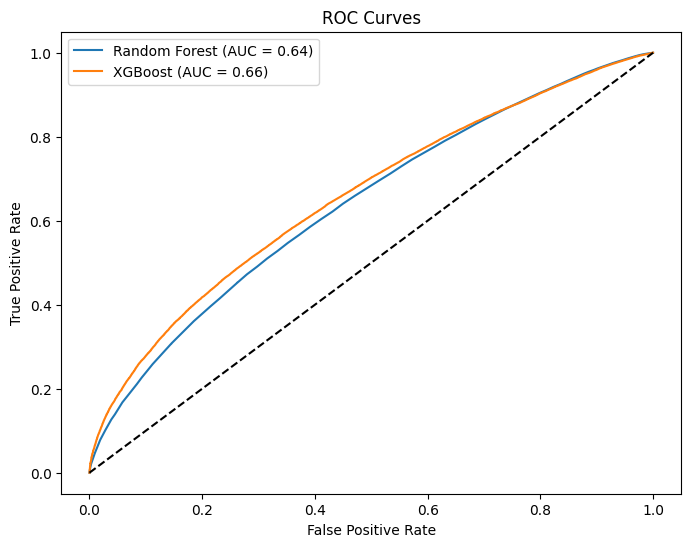

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


In [ ]:
# Correlation check
correlations = df.corr()['fully_funded'].sort_values(ascending=False)
print(correlations.head(15))


fully_funded                                   1.000000
eligible_double_your_impact_match_t            0.097188
school_metro_urban                             0.094258
poverty_level_highest poverty                  0.078789
teacher_teach_for_america_t                    0.069738
eligible_almost_home_match_t                   0.055720
school_state_NY                                0.054228
teacher_prefix_Ms.                             0.050014
primary_focus_subject_Environmental Science    0.036659
school_state_CA                                0.034571
primary_focus_area_Math & Science              0.032802
school_charter_t                               0.032069
primary_focus_area_Music & The Arts            0.030554
primary_focus_subject_Music                    0.025463
school_state_DC                                0.024877
Name: fully_funded, dtype: float64


In [ ]:
# Assuming you kept the original (non-encoded) version of X
# Add group info back using index alignment
demographics_test = demographics.loc[X_test.index]
test_results['poverty_level'] = demographics_test['poverty_level'].values
test_results['school_metro'] = demographics_test['school_metro'].values


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

def compute_fairness(df, group_col):
    results = []

    for group in df[group_col].unique():
        sub = df[df[group_col] == group]
        y_true = sub['y_true']
        y_pred = sub['y_pred']

        if len(np.unique(y_true)) < 2:
            continue  # Skip if only one class exists

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        TPR = tp / (tp + fn) if (tp + fn) > 0 else 0
        FPR = fp / (fp + tn) if (fp + tn) > 0 else 0
        PPR = (tp + fp) / len(sub)

        results.append({
            group_col: group,
            'TPR': TPR,
            'FPR': FPR,
            'PPR': PPR,
            'Support': len(sub)
        })

    return pd.DataFrame(results)


In [ ]:
test_results = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': y_pred,
    'y_prob': y_prob,
})
test_results['poverty_level'] = demographics_test['poverty_level'].values[:len(test_results)]
test_results['school_metro'] = demographics_test['school_metro'].values[:len(test_results)]

poverty_fairness = compute_fairness(test_results, 'poverty_level')
print("Fairness by Poverty Level:\n", poverty_fairness)

metro_fairness = compute_fairness(test_results, 'school_metro')
print("\nFairness by School Metro Type:\n", metro_fairness)


Fairness by Poverty Level:
       poverty_level       TPR       FPR       PPR  Support
0   highest poverty  0.787169  0.586682  0.732125    71873
1       low poverty  0.690274  0.567961  0.648764     3035
2      high poverty  0.772205  0.610372  0.717244    32307
3  moderate poverty  0.735104  0.606940  0.688968    16651

Fairness by School Metro Type:
   school_metro       TPR       FPR       PPR  Support
0        urban  0.781573  0.577517  0.727634    65860
1     suburban  0.752574  0.596622  0.702241    28251
2        rural  0.783207  0.626405  0.721075    14814


In [ ]:
projects.head()

In [ ]:
outcomes.head()

In [ ]:
essays.head()

In [ ]:
resources.head()

fully_funded
t    0.695406
f    0.304594
Name: proportion, dtype: float64


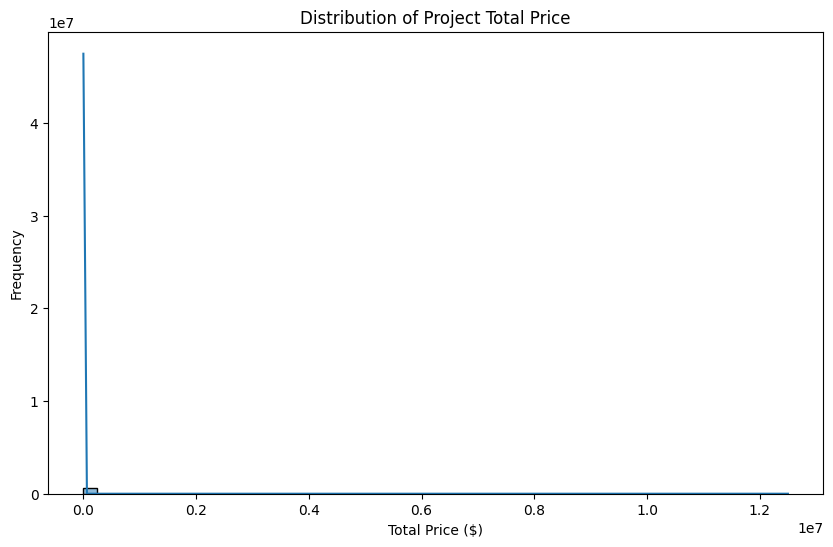

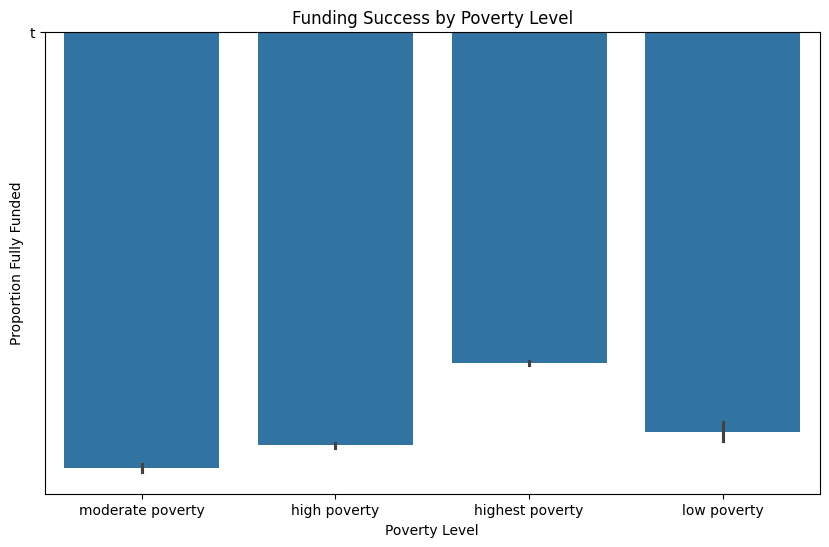

In [ ]:
# Check distribution of fully funded projects
print(data['fully_funded'].value_counts(normalize=True))

# Distribution of total project cost
plt.figure(figsize=(10, 6))
sns.histplot(data['total_price_including_optional_support'], bins=50, kde=True)
plt.title('Distribution of Project Total Price')
plt.xlabel('Total Price ($)')
plt.ylabel('Frequency')
plt.show()

# Funding success by poverty level
plt.figure(figsize=(10, 6))
sns.barplot(x='poverty_level', y='fully_funded', data=data, estimator=np.mean)
plt.title('Funding Success by Poverty Level')
plt.xlabel('Poverty Level')
plt.ylabel('Proportion Fully Funded')
plt.show()


#missing values and box plots/outliers - make sure

In [ ]:

# Feature selection
features = [
    'school_metro', 'school_charter', 'school_magnet', 'poverty_level',
    'grade_level', 'total_price_including_optional_support',
    'students_reached', 'eligible_double_your_impact_match',
    'total_resource_cost', 'mean_item_cost', 'total_items'
]

X = data[features]
y = data['fully_funded']

# Preprocessing categorical variables
X = pd.get_dummies(X, drop_first=True)

# Handle missing values
X.fillna(X.median(), inplace=True)

#standardizing dataset - poverty lev - funding - bigger values

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20, stratify=y
)

# Model training
model = LogisticRegression(max_iter=1000, random_state=20) #changing rs
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Model evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Report:
               precision    recall  f1-score   support

           f       0.58      0.08      0.14     37729
           t       0.71      0.98      0.82     86137

    accuracy                           0.70    123866
   macro avg       0.64      0.53      0.48    123866
weighted avg       0.67      0.70      0.61    123866

ROC-AUC Score: 0.6600652142346561


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain logistic regression with scaled data
model_scaled = LogisticRegression(max_iter=1000, random_state=20)
model_scaled.fit(X_train_scaled, y_train)

# Evaluate again
y_pred_scaled = model_scaled.predict(X_test_scaled)
y_proba_scaled = model_scaled.predict_proba(X_test_scaled)[:, 1]

print("Classification Report (Scaled Data):\n", classification_report(y_test, y_pred_scaled))
print("ROC-AUC Score (Scaled Data):", roc_auc_score(y_test, y_proba_scaled))


Classification Report (Scaled Data):
               precision    recall  f1-score   support

           f       0.58      0.08      0.14     37729
           t       0.71      0.98      0.82     86137

    accuracy                           0.70    123866
   macro avg       0.64      0.53      0.48    123866
weighted avg       0.67      0.70      0.61    123866

ROC-AUC Score (Scaled Data): 0.6600869373050621


In [ ]:
# Logistic regression with balanced class weights
model_balanced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=20)
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)
y_proba_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]

print("Classification Report (Balanced Classes):\n", classification_report(y_test, y_pred_balanced))
print("ROC-AUC Score (Balanced Classes):", roc_auc_score(y_test, y_proba_balanced))


Classification Report (Balanced Classes):
               precision    recall  f1-score   support

           f       0.43      0.58      0.49     37729
           t       0.78      0.67      0.72     86137

    accuracy                           0.64    123866
   macro avg       0.61      0.62      0.61    123866
weighted avg       0.68      0.64      0.65    123866

ROC-AUC Score (Balanced Classes): 0.6677001356050755


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=20, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Random Forest ROC-AUC Score:", roc_auc_score(y_test, y_proba_rf))


Random Forest Classification Report:
               precision    recall  f1-score   support

           f       0.50      0.28      0.36     37729
           t       0.74      0.88      0.80     86137

    accuracy                           0.70    123866
   macro avg       0.62      0.58      0.58    123866
weighted avg       0.67      0.70      0.67    123866

Random Forest ROC-AUC Score: 0.6748826425021902


In [ ]:
# Convert training labels from 'f'/'t' to 0/1
y_train_bin = y_train.map({'f': 0, 't': 1})
y_test_bin = y_test.map({'f': 0, 't': 1})


from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Compute class imbalance ratio for scale_pos_weight
scale_pos_weight = (len(y_train_bin) - sum(y_train_bin)) / sum(y_train_bin)

# Train the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          scale_pos_weight=scale_pos_weight,
                          random_state=20)
xgb_model.fit(X_train, y_train_bin)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("XGBoost Classification Report:\n", classification_report(y_test_bin, y_pred_xgb))
print("XGBoost ROC-AUC Score:", roc_auc_score(y_test_bin, y_proba_xgb))

#support - 1 bigger imbalanced - make sure is balanced. almost equal. drop data-not recommended

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:25:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.69      0.53     37729
           1       0.82      0.60      0.69     86137

    accuracy                           0.63    123866
   macro avg       0.62      0.65      0.61    123866
weighted avg       0.70      0.63      0.64    123866

XGBoost ROC-AUC Score: 0.7020287884928245


In [ ]:
import pandas as pd

# Add model predictions and actual labels back into test data
test_results = X_test.copy()
test_results['y_true'] = y_test_bin
test_results['y_pred'] = y_pred_xgb
test_results['y_proba'] = y_proba_xgb

# Include sensitive attributes (poverty_level, school_metro)
test_results['poverty_level'] = data.loc[X_test.index, 'poverty_level'].values
test_results['school_metro'] = data.loc[X_test.index, 'school_metro'].values



In [ ]:
from sklearn.metrics import confusion_matrix

def fairness_metrics(df, group_col):
    groups = df[group_col].unique()
    metrics = []

    for group in groups:
        subset = df[df[group_col] == group]
        tn, fp, fn, tp = confusion_matrix(subset['y_true'], subset['y_pred']).ravel()

        tpr = tp / (tp + fn)  # True Positive Rate
        fpr = fp / (fp + tn)  # False Positive Rate
        ppr = (tp + fp) / len(subset)  # Positive Prediction Rate

        metrics.append({
            group_col: group,
            'TPR': tpr,
            'FPR': fpr,
            'PPR': ppr
        })

    return pd.DataFrame(metrics)
#all imports in one cell in the beggining

In [ ]:
poverty_fairness = fairness_metrics(test_results, 'poverty_level')
print("Fairness Metrics by Poverty Level:\n", poverty_fairness)


Fairness Metrics by Poverty Level:
       poverty_level       TPR       FPR       PPR
0   highest poverty  0.681224  0.380631  0.598695
1       low poverty  0.461845  0.274757  0.398353
2      high poverty  0.502742  0.240977  0.413842
3  moderate poverty  0.415877  0.201702  0.338778


In [ ]:
from sklearn.metrics import confusion_matrix

def fairness_metrics(df, group_col):
    groups = df[group_col].unique()
    metrics = []

    for group in groups:
        subset = df[df[group_col] == group]
        y_true = subset['y_true']
        y_pred = subset['y_pred']

        # Check if subgroup has both classes
        if len(np.unique(y_true)) < 2:
            print(f"Warning: '{group}' in '{group_col}' has only one class in true labels. Skipping.")
            continue

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        tpr = tp / (tp + fn)  # True Positive Rate
        fpr = fp / (fp + tn)  # False Positive Rate
        ppr = (tp + fp) / len(subset)  # Positive Prediction Rate

        metrics.append({
            group_col: group,
            'TPR': tpr,
            'FPR': fpr,
            'PPR': ppr
        })

    return pd.DataFrame(metrics)


metro_fairness = fairness_metrics(test_results, 'school_metro')
print("Fairness Metrics by School Metro Type:\n", metro_fairness)


Fairness Metrics by School Metro Type:
   school_metro       TPR       FPR       PPR
0        urban  0.706755  0.415877  0.629866
1     suburban  0.503528  0.266067  0.426888
2        rural  0.400827  0.168995  0.308964


In [ ]:
# Add impact score: Probability(unfunded) * students impacted
test_results['expected_impact'] = test_results['y_proba'] * data.loc[test_results.index, 'students_reached']

# Sort by expected impact
priority_projects = test_results.sort_values(by='expected_impact', ascending=False)

# Top 10 priority projects
print(priority_projects[['expected_impact', 'students_reached', 'y_proba']].head(10))


        expected_impact  students_reached   y_proba
451735     10844.373107           15000.0  0.722958
470762      9620.465040           10000.0  0.962047
607949      7543.140146           10031.0  0.751983
552482      4083.779752            5000.0  0.816756
159753      3918.210585            7030.0  0.557356
508342      2793.197930            5000.0  0.558640
476780      2726.731360            3000.0  0.908910
465658      2127.676785            2250.0  0.945634
460456      1907.741427            2000.0  0.953871
427302      1888.734460            2000.0  0.944367


In [ ]:
from textblob import TextBlob

essays['sentiment'] = essays['essay'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Merge sentiment scores back into test_results
test_results['essay_sentiment'] = essays.loc[test_results.index, 'sentiment']

# Low-sentiment projects might require expert review
priority_essay_projects = test_results[test_results['essay_sentiment'] < essays['sentiment'].quantile(0.25)]
priority_essay_projects = priority_essay_projects.sort_values(by='y_proba', ascending=False)

print(priority_essay_projects[['essay_sentiment', 'y_proba']].head(10))
# 3 models engough - cross validaton kfold / hyperpara tuning - best perf model

        essay_sentiment   y_proba
617889         0.119376  0.999159
619096         0.125000  0.999084
617998         0.131074  0.998651
617793         0.055437  0.998434
618455         0.070833  0.998229
618609         0.043146  0.997783
618144         0.082474  0.997426
618574        -0.013542  0.996893
618572         0.067585  0.996666
618564         0.109028  0.996508


In [ ]:
# Assume expert review improves funding probability by 20%
improvement_factor = 0.20
test_results['improved_proba'] = test_results['y_proba'] - (test_results['y_proba'] * improvement_factor)

# Count additional projects potentially funded
threshold = 0.5
original_funded = sum(test_results['y_proba'] < threshold)
after_intervention = sum(test_results['improved_proba'] < threshold)

additional_funded_projects = after_intervention - original_funded
print(f"Additional projects potentially funded: {additional_funded_projects}")

# Total additional students benefiting
additional_students = test_results[
    (test_results['y_proba'] >= threshold) & (test_results['improved_proba'] < threshold)
]['students_reached'].sum()

print(f"Additional students potentially impacted: {additional_students}")


Additional projects potentially funded: 26435
Additional students potentially impacted: 2382556.0


In [ ]:
# Prioritize highest-poverty schools with high unfunded likelihood
test_results['school_city'] = data.loc[test_results.index, 'school_city'].values

# Now re-run the prioritization:
high_poverty_priority = test_results[
    (test_results['poverty_level'] == 'highest poverty')
].sort_values(by='y_proba', ascending=False)

top_high_poverty_projects = high_poverty_priority.head(10)

print(top_high_poverty_projects[['y_proba', 'students_reached', 'school_city']])


         y_proba  students_reached school_city
617889  0.999159               0.0    Brooklyn
617427  0.999111               0.0    New York
619096  0.999084               0.0    New York
618191  0.998657               0.0    New York
617998  0.998651               0.0    New York
617793  0.998434               0.0       Bronx
618067  0.998360               0.0    New York
618075  0.998309               0.0    New York
618455  0.998229               0.0       Bronx
617986  0.997934               0.0    New York


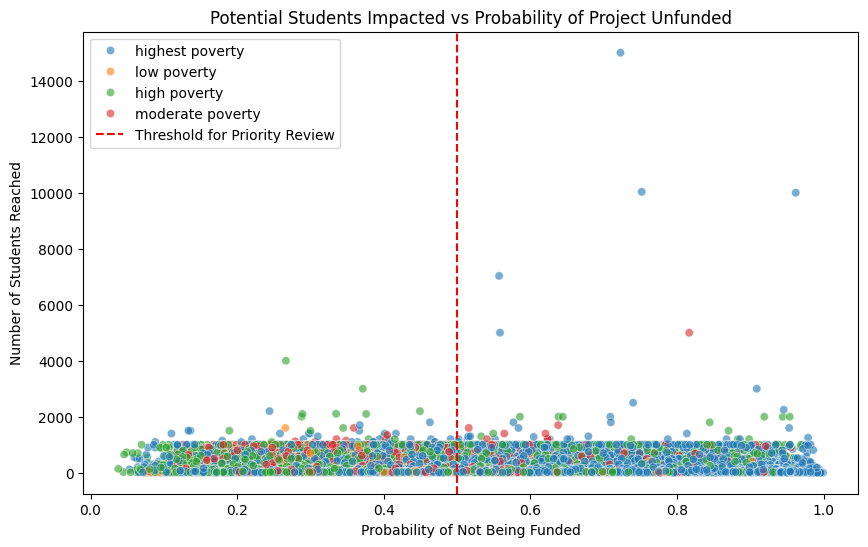

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize impact on students reached by funding probability
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=test_results,
    x='y_proba', y='students_reached', hue='poverty_level', alpha=0.6
)
plt.title("Potential Students Impacted vs Probability of Project Unfunded")
plt.xlabel("Probability of Not Being Funded")
plt.ylabel("Number of Students Reached")
plt.axvline(0.5, color='red', linestyle='--', label='Threshold for Priority Review')
plt.legend()
plt.show()


In [ ]:
import folium

map_center = [40.7128, -74.0060]  # NYC center for this example
edu_map = folium.Map(location=map_center, zoom_start=10)

for _, row in top_high_poverty_projects.iterrows():
    folium.Marker(
        location=[data.loc[row.name, 'school_latitude'], data.loc[row.name, 'school_longitude']],
        popup=f"{row['school_city']} | P(unfunded): {row['y_proba']:.2f}"
    ).add_to(edu_map)

edu_map


In [ ]:
# Create sentiment quartile groups
test_results['sentiment_group'] = pd.qcut(test_results['essay_sentiment'], 4, labels=["Very Low", "Low", "High", "Very High"])

# Average funding risk per group
risk_by_sentiment = test_results.groupby('sentiment_group')['y_proba'].mean()
print(risk_by_sentiment)


sentiment_group
Very Low     0.528892
Low          0.526775
High         0.527978
Very High    0.528494
Name: y_proba, dtype: float32


<ipython-input-44-fe9ad8bac0e4>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_by_sentiment = test_results.groupby('sentiment_group')['y_proba'].mean()


In [ ]:
# all best models / eval scores reach to conclusion for recommendation to the stake holder.
#